In [1]:
# Basic libraries
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [3]:
# Load clustered dataset
df = pd.read_csv(r"C:\Users\Jayan Gamage\pima-diabetes-analysis\data\clustered_diabetes.csv")

# Quick check
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Risk,Cluster
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1,Obese,Middle,High,2
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0,Overweight,Middle,Normal,1
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1,Normal,Middle,High,2
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0,Overweight,Young,Normal,1
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1,Obese,Middle,Prediabetic,0


In [4]:
# Select key predictors
X = df[['Glucose', 'BMI', 'Age', 'Pregnancies']]
y = df['Outcome']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [5]:
#Logistic Regression Model

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


Logistic Regression Results
Accuracy: 0.7012987012987013
Precision: 0.58
Recall: 0.5370370370370371
F1 Score: 0.5576923076923077
Confusion Matrix:
 [[79 21]
 [25 29]]


In [6]:
#Random Forest Model

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Results
Accuracy: 0.7142857142857143
Precision: 0.6
Recall: 0.5555555555555556
F1 Score: 0.5769230769230769
Confusion Matrix:
 [[80 20]
 [24 30]]


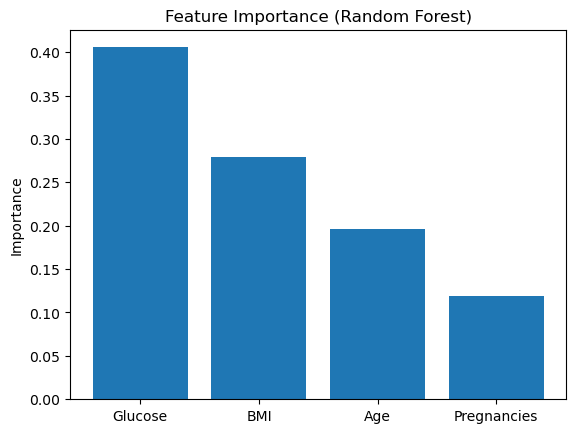

In [7]:
#Feature Importance (Random Forest)

importances = rf.feature_importances_
features = X.columns

plt.bar(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()


In [8]:
# Collect metrics for both models
results = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
}

# Convert to DataFrame for easy display
results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.701299       0.58  0.537037  0.557692
1        Random Forest  0.714286       0.60  0.555556  0.576923


Logistic Regression → simpler, interpretable, but slightly lower performance.

Random Forest → stronger accuracy and balanced metrics, but less interpretable.

Both models show moderate predictive power (~70–71% accuracy), consistent with the dataset’s complexity.

Business takeaway: Glucose and BMI remain the most important predictors, aligning with your EDA and cluster analysis.

#### Business Problem

Diabetes is a growing public health issue.

Goal: predict risk using patient data (glucose, BMI, age, pregnancies).

Supports early screening and efficient resource allocation.

#### Model Building

Logistic Regression - baseline, simple and interpretable.

Random Forest - stronger, captures non‑linear patterns, shows feature importance.

#### Performance Evaluation

Logistic Regression: Accuracy 0.70, Precision 0.58, Recall 0.54, F1 0.56.

Random Forest: Accuracy 0.71, Precision 0.60, Recall 0.56, F1 0.58.

Both show moderate predictive power; Random Forest slightly stronger.

#### Business Impact

Enables targeted screening of high‑risk patients.

Guides preventive health campaigns (focus on glucose and BMI).

Improves resource allocation in healthcare systems.

#### Scalability & Deployment

Can be integrated into dashboards or EHR systems.

Uses standard clinical measures → scalable across populations.

Requires periodic retraining to stay relevant.